1. Define a simple signal to be encoded:

Number of samples: 256
Total duration: 32.00 ms
Sampling rate: 8000 Hz
Frequency: 700 Hz


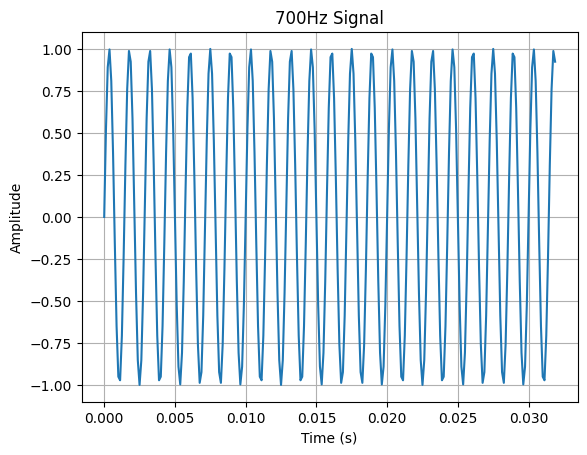

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
fs = 8000  # Sampling rate
f = 700  # Frequency of the signal in Hz
N = 256  # Number of samples

t = np.arange(N) / fs  # Time vector for N samples. 80 samples would be close to the minimum perceptible for 700Hz with 8kHz sampling rate
signal = np.sin(2 * np.pi * f * t)  # Generate the signal

# Print number of samples, total milliseconds, sampling rate and frequency
print(f'Number of samples: {len(signal)}')
print(f'Total duration: {len(signal) / fs * 1000:.2f} ms')
print(f'Sampling rate: {fs} Hz')
print(f'Frequency: {f} Hz')

# Plot the signal
plt.plot(t, signal)
plt.title(f'{f}Hz Signal')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid()
plt.show()

2. Test signal audability:

In [ ]:
from IPython.display import Audio
# Play the audio signal
Audio(signal, rate=fs)

3. Encode a and decode as QCrank state:

        ┌───┐»
addr_0: ┤ H ├»
        ├───┤»
addr_1: ┤ H ├»
        ├───┤»
addr_2: ┤ H ├»
        ├───┤»
addr_3: ┤ H ├»
        ├───┤»
addr_4: ┤ H ├»
        ├───┤»
addr_5: ┤ H ├»
        ├───┤»
addr_6: ┤ H ├»
        ├───┤»
addr_7: ┤ H ├»
        └───┘»
     x: ─────»
             »
«        ┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

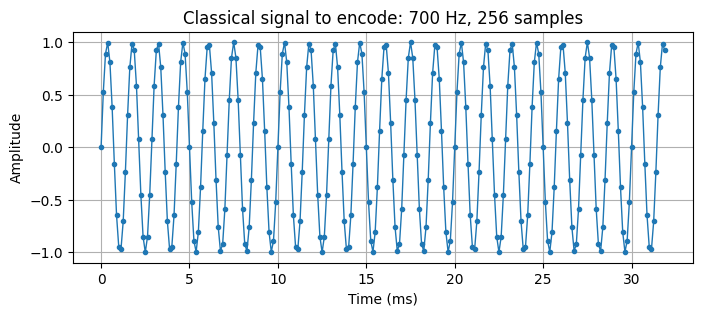

In [14]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.library import UCRYGate

# ------------------------------------------------------------
# 1. QCrank/EVEN angles
#    x_i = <Z>_i after conditioning on address i
# ------------------------------------------------------------

# Make sure the audio is inside the EVEN/QCrank domain [-1, 1]
signal = np.clip(signal, -1.0, 1.0)

theta = np.arccos(signal)   # theta_i in [0, pi]


# ------------------------------------------------------------
# 2. QCrank circuit
#    8 address qubits + 1 data qubit = 9 qubits
# ------------------------------------------------------------
n_addr = int(np.log2(N))
assert 2**n_addr == N, "QCrank address size requires N to be a power of two."

addr = QuantumRegister(n_addr, "addr")
data = QuantumRegister(1, "x")

qc_qcrank = QuantumCircuit(addr, data, name="QCrank_audio_256")

# Uniform superposition over all sample addresses |i>
qc_qcrank.h(addr)

# Uniformly controlled Ry:
# For each address |i>, apply Ry(theta[i]) to the data qubit.
#
# Qiskit UCRYGate convention:
# qubit 0 of the gate is the target, remaining qubits are controls.
qc_qcrank.append(UCRYGate(theta.tolist()), [data[0]] + list(addr))

print(qc_qcrank)
print(f"QCrank audio circuit qubits: {qc_qcrank.num_qubits}")
print(f"QCrank audio circuit operations: {qc_qcrank.count_ops()}")

# ------------------------------------------------------------
# 3. Optional measurement circuit for later reconstruction
#    Do NOT measure here if you want to append EHands operations.
# ------------------------------------------------------------
c_addr = ClassicalRegister(n_addr, "c_addr")
c_data = ClassicalRegister(1, "c_x")

qc_meas = qc_qcrank.copy(name="QCrank_audio_256_measured")
qc_meas.add_register(c_addr)
qc_meas.add_register(c_data)

qc_meas.measure(addr, c_addr)
qc_meas.measure(data[0], c_data[0])

# ------------------------------------------------------------
# 4. Plot the encoded classical signal
# ------------------------------------------------------------
plt.figure(figsize=(8, 3))
plt.plot(t * 1000, signal, marker=".", linewidth=1)
plt.title(f"Classical signal to encode: {f} Hz, {N} samples")
plt.xlabel("Time (ms)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()